In [1]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd

import re

In [2]:
#load in just the Arabidopsis Data set
df3 = pd.read_csv("/home/wenyuantong/Desktop/data/arabi_cross/100_150.csv", index_col=0)
df3.head()

,F4IB81_middle_191_325,Q0WP38_N-terminal_1_127,Q7XA66_C-terminal_93_242,Q8LAF9_N-terminal_1_113,Q940Y9_N-terminal_1_126,Q9C5H4_middle_131_261,Q9LNP6_C-terminal_213_328,Q9LUZ5_N-terminal_1_100,Q9LUZ5_middle_517_622,Q9SCU5_C-terminal_406_549,...,Q9C9J1_N-terminal_1_100,Q9CAV6_middle_290_393,Q9FMK8_IDP_1_138,Q9M0V4_N-terminal_1_131,Q9M158_N-terminal_1_104,F4I4Q1_C-terminal_188_303,Q6NN00_IDP_1_116,Q8VY68_IDP_1_113,Q9SZD3_IDP_1_115,Q9XFB0_N-terminal_1_115
F4IB81_middle_191_325,2.173744,4.955565,2.731385,1.004872,1.413445,2.018600,0.547160,2.448571,1.671656,0.792111,...,2.247709,-1.459587,2.059876,4.283379,2.857878,6.205853,3.050188,1.032668,1.311511,1.793946
Q0WP38_N-terminal_1_127,5.267727,15.548567,2.460256,0.243044,0.598914,3.479011,1.330661,6.113140,-5.940918,5.057411,...,1.999173,3.590195,0.562825,12.914173,4.733822,18.148154,8.185653,-0.061797,3.231808,1.948292
Q7XA66_C-terminal_93_242,2.458247,2.083016,4.102955,2.436277,3.095957,2.333399,1.293153,1.826779,5.169203,0.368553,...,3.267093,-2.266097,3.505828,1.571661,2.880411,2.355006,2.408988,2.570691,1.762559,3.112770
Q8LAF9_N-terminal_1_113,1.200511,0.273156,3.233996,1.537261,2.463209,0.900981,0.404432,0.918357,5.972982,-0.803547,...,2.594724,-3.640606,3.084627,0.200220,1.841420,0.710283,0.784952,1.659385,-0.169089,2.587987
Q940Y9_N-terminal_1_126,1.514405,0.603668,3.685663,2.209068,2.495591,1.997687,0.774155,1.172006,5.608511,-0.442412,...,2.929752,-3.110195,3.314959,0.858460,2.453430,1.005241,1.343525,2.286190,1.284145,2.456314


In [3]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'

matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [4]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [5]:
mode='mpipi'

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list,fcluster
import matplotlib.patches as mpatches

In [8]:
%%time
# calculate the linkage relationships
# NOTE - this takes ~5 min to run because of the optimal_ordering keyword
row_linkage = linkage(df3, method='ward', optimal_ordering=True)
col_linkage = linkage(df3.T, method='ward',optimal_ordering=True)  # Transpose for column clustering
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

CPU times: user 17min 15s, sys: 0 ns, total: 17min 15s
Wall time: 17min 11s


In [9]:

df_numbered_indices = df3.copy()
df_numbered_indices.index = range(len(df3.index)) # Assign new numerical row index
df_numbered_indices.columns = range(len(df3.columns)) # Assign new numerical column index

print("\nNew DataFrame with numerical indices:")
display(df_numbered_indices)


New DataFrame with numerical indices:


,0,1,2,3,4,5,6,7,8,9,...,3730,3731,3732,3733,3734,3735,3736,3737,3738,3739
0,2.173744,4.955565,2.731385,1.004872,1.413445,2.018600,0.547160,2.448571,1.671656,0.792111,...,2.247709,-1.459587,2.059876,4.283379,2.857878,6.205853,3.050188,1.032668,1.311511,1.793946
1,5.267727,15.548567,2.460256,0.243044,0.598914,3.479011,1.330661,6.113140,-5.940918,5.057411,...,1.999173,3.590195,0.562825,12.914173,4.733822,18.148154,8.185653,-0.061797,3.231808,1.948292
2,2.458247,2.083016,4.102955,2.436277,3.095957,2.333399,1.293153,1.826779,5.169203,0.368553,...,3.267093,-2.266097,3.505828,1.571661,2.880411,2.355006,2.408988,2.570691,1.762559,3.112770
3,1.200511,0.273156,3.233996,1.537261,2.463209,0.900981,0.404432,0.918357,5.972982,-0.803547,...,2.594724,-3.640606,3.084627,0.200220,1.841420,0.710283,0.784952,1.659385,-0.169089,2.587987
4,1.514405,0.603668,3.685663,2.209068,2.495591,1.997687,0.774155,1.172006,5.608511,-0.442412,...,2.929752,-3.110195,3.314959,0.858460,2.453430,1.005241,1.343525,2.286190,1.284145,2.456314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3735,7.222329,19.869100,3.045266,0.691913,1.091900,4.743132,2.318450,7.726050,-8.374600,7.239051,...,2.510099,6.113808,0.548143,16.246550,5.876947,22.790970,10.697309,0.301763,4.959385,2.765082
3736,3.549787,8.961879,3.115070,0.764652,1.459346,3.281612,1.045636,4.019763,-0.653231,2.500693,...,2.674637,0.312388,2.208402,7.585685,4.311010,10.697309,5.696523,0.790325,2.262997,1.837291
3737,1.233718,-0.069453,3.412422,1.659385,2.549204,1.178093,0.562882,0.864295,6.087566,-0.887892,...,2.763604,-3.591576,3.385901,0.072136,2.039640,0.309775,0.811307,1.887097,0.247034,2.595617
3738,1.539600,3.569040,2.298990,-0.166148,1.406976,0.836644,-0.234359,1.712972,2.800783,-0.246760,...,2.027605,-2.723561,2.433139,3.004833,2.407152,5.002510,2.282675,0.242738,-0.596902,1.489163


In [13]:
# Check the dtype of your DataFrame's index
df_index_dtype = df_numbered_indices.index.dtype
print(f"DataFrame index dtype: {df_index_dtype}")

DataFrame index dtype: int64


In [14]:
compatible_row_order = pd.Index(row_order, dtype=df_index_dtype)

In [15]:
compatible_col_order = pd.Index(col_order, dtype=df_index_dtype)

In [16]:
# reorder the matrix based on this set of linkage relationships
reordered_matrix =  df_numbered_indices.loc[compatible_row_order, compatible_col_order]

In [17]:
reordered_matrix

,2561,2120,3558,371,2185,3501,736,3391,1001,1034,...,1540,2512,1937,1655,2990,1954,1119,377,819,614
2185,80.816285,84.170128,80.352942,83.871519,106.760418,58.588303,62.891397,66.354798,63.898965,59.479186,...,-12.756907,-11.554658,-15.423619,-13.264894,-11.465627,-20.088064,-20.215772,-16.452474,-16.826103,-15.013512
2277,70.932342,74.733380,71.530894,75.176280,94.976354,52.207539,56.140009,58.986330,56.966751,53.033472,...,-12.556404,-11.357281,-14.341611,-11.974992,-10.378169,-18.583984,-19.327961,-15.452708,-15.914752,-14.737728
3478,70.801385,74.547044,71.299181,74.733142,94.746861,52.077463,55.889272,58.748305,56.669980,52.876274,...,-11.832768,-10.850468,-14.139291,-12.089892,-10.612528,-18.278628,-18.251328,-15.201145,-15.261063,-13.669834
371,71.004270,74.084891,70.764040,73.918200,93.700212,51.878803,55.885311,58.818260,56.512738,52.712580,...,-10.655458,-9.426734,-12.560174,-10.500291,-8.916328,-16.631970,-17.340136,-13.650209,-14.390877,-13.453001
3558,65.093029,68.868154,65.943367,69.143489,87.713517,48.186296,51.686460,54.332855,52.520377,48.838657,...,-11.585002,-10.629720,-13.521488,-11.604641,-10.187978,-17.439347,-17.691768,-14.598893,-14.771021,-13.355598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2528,-8.753127,-5.700088,-5.416364,-5.977419,-9.300571,-0.289206,-0.472028,-1.781010,-3.020523,-1.552191,...,9.733693,10.025533,10.749809,10.061097,10.504592,12.104115,10.799751,9.510396,8.244487,5.986767
1791,-10.293518,-6.894508,-6.622156,-7.308879,-10.321064,-1.087107,-1.783113,-3.014399,-4.136914,-2.711034,...,9.534000,9.693747,10.279257,9.140448,9.495917,11.826553,11.100577,9.071013,8.216380,6.583279
3498,-14.748485,-9.829754,-9.075524,-8.949060,-13.562587,-2.373531,-3.664413,-5.264784,-6.374938,-4.930350,...,8.409833,9.128800,10.229761,9.900927,10.188530,11.510375,9.701631,8.942425,7.617236,5.855216
677,-38.806235,-34.519597,-32.496513,-33.640936,-45.095103,-18.605370,-21.145959,-23.741419,-24.808459,-22.045134,...,14.469377,15.206069,17.496350,16.036321,16.226715,20.120093,17.541950,16.255336,13.928551,11.498102


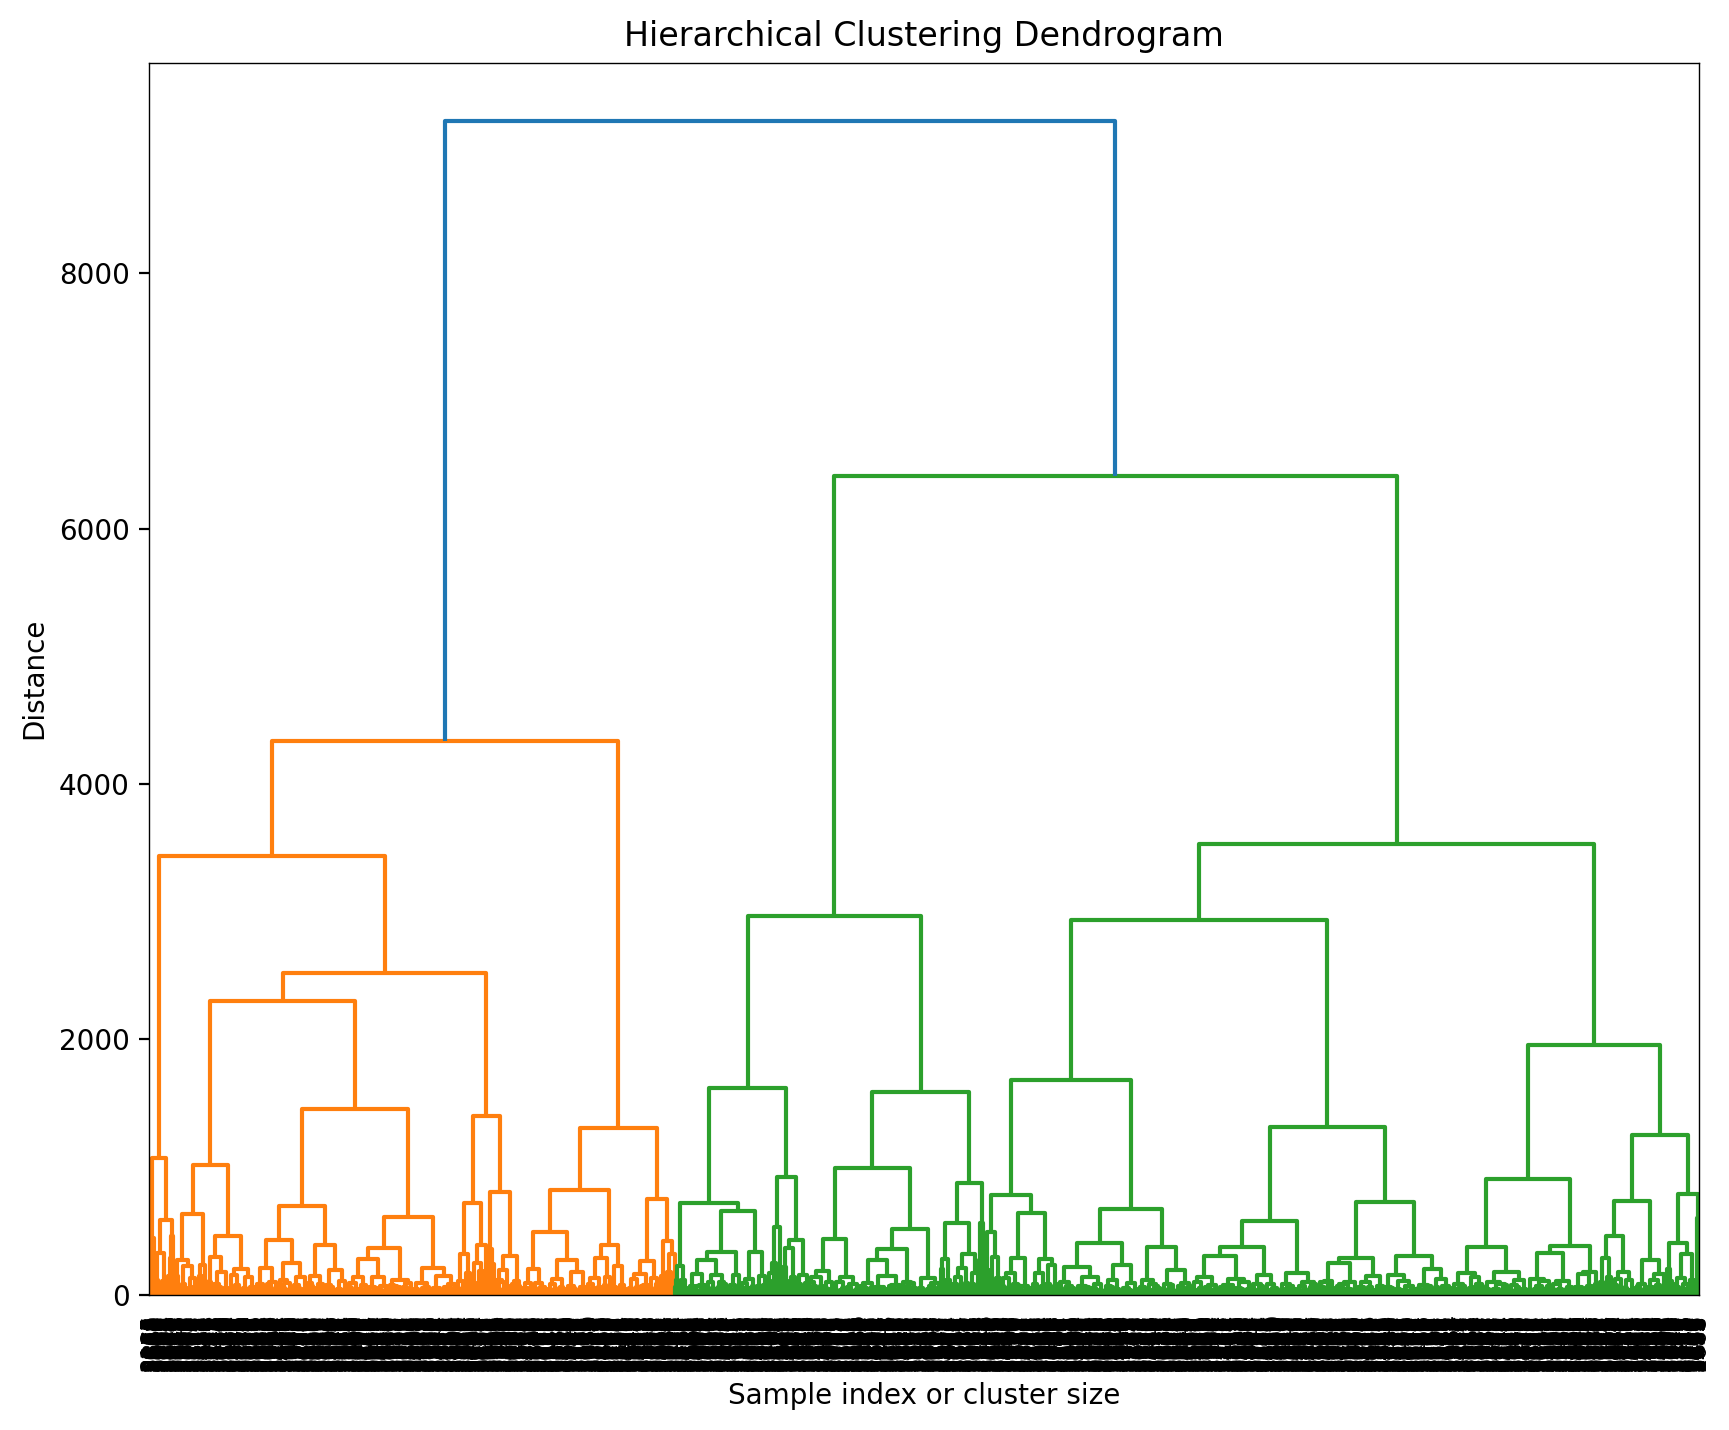

In [18]:
#Z = linkage(X, 'ward')
#row_linkage
#col_linkage

# 3. Plot the dendrogram
plt.figure(figsize=(10, 8))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')

dendrogram(
    row_linkage,
    leaf_rotation=90.,  # Rotates the x-axis labels
    leaf_font_size=8.,  # Adjusts the font size for the labels
)

plt.show()

In [19]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def calculate_cosine_within_cluster_similarity(data_matrix, labels):
    """
    Calculates the average within-cluster cosine similarity.
    Similarity is calculated between each point and its cluster centroid.
    """
    unique_labels = np.unique(labels)
    within_similarities = []

    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        if cluster_points.shape[0] > 1:
            centroid = cluster_points.mean(axis=0)
            centroid = centroid.reshape(1, -1) # Reshape for cosine_similarity
            sim = cosine_similarity(cluster_points, centroid)
            within_similarities.append(np.mean(sim))
        elif cluster_points.shape[0] == 1:
            # A single-point cluster has perfect similarity to itself
            within_similarities.append(1.0)

    if len(within_similarities) > 0:
        return np.mean(within_similarities)
    return 0.0

def calculate_cosine_between_cluster_similarity(data_matrix, labels):
    """
    Calculates the average between-cluster cosine similarity.
    Similarity is calculated between centroids of different clusters.
    """
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0 # Cannot calculate between-cluster similarity with less than 2 clusters

    cluster_centroids = {}
    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        cluster_centroids[label] = cluster_points.mean(axis=0)

    between_similarities = []
    # Iterate through unique pairs of clusters
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            label1 = unique_labels[i]
            label2 = unique_labels[j]

            centroid1 = cluster_centroids[label1].reshape(1, -1)
            centroid2 = cluster_centroids[label2].reshape(1, -1)

            sim = cosine_similarity(centroid1, centroid2)[0][0]
            between_similarities.append(sim)

    if len(between_similarities) > 0:
        return np.mean(between_similarities)
    return 0.0

In [23]:
Z = row_linkage
df = reordered_matrix

In [24]:

results = []
for n_clusters in range(2, 25):
    # Get cluster labels for the current number of clusters
    labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Calculate similarities
    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df3.values, labels)

    results.append({
        'n_clusters': n_clusters,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

# Convert results to a DataFrame for easier analysis and display
results_df = pd.DataFrame(results)
display(results_df.head())

,n_clusters,within_cluster_similarity,between_cluster_similarity
0,2,0.812751,0.677374
1,3,0.806690,0.525123
2,4,0.810314,0.574550
3,5,0.810723,0.639104
4,6,0.811885,0.599292


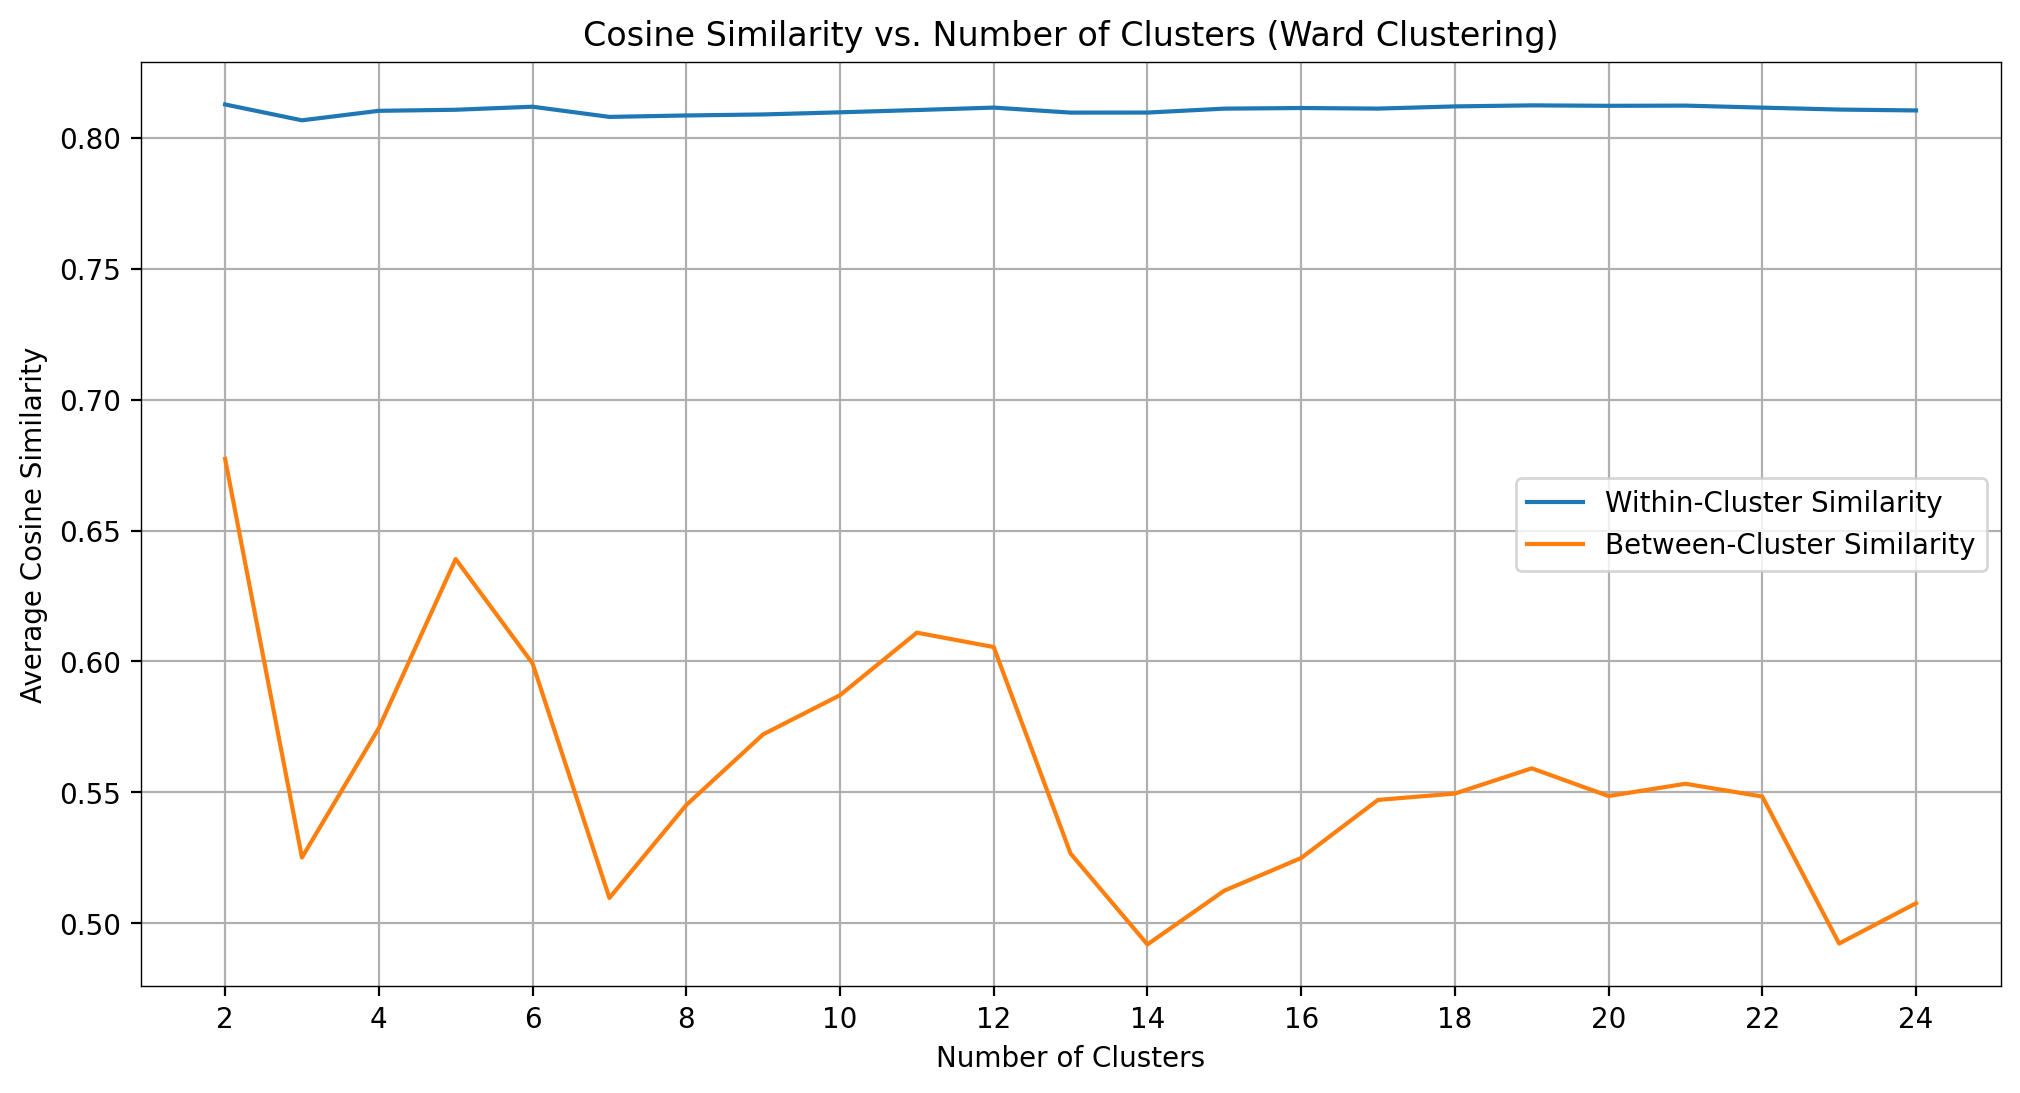

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=results_df, label='Between-Cluster Similarity')
plt.title('Cosine Similarity vs. Number of Clusters (Ward Clustering)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, 25, 2))
plt.grid(True)
plt.legend()
plt.show()

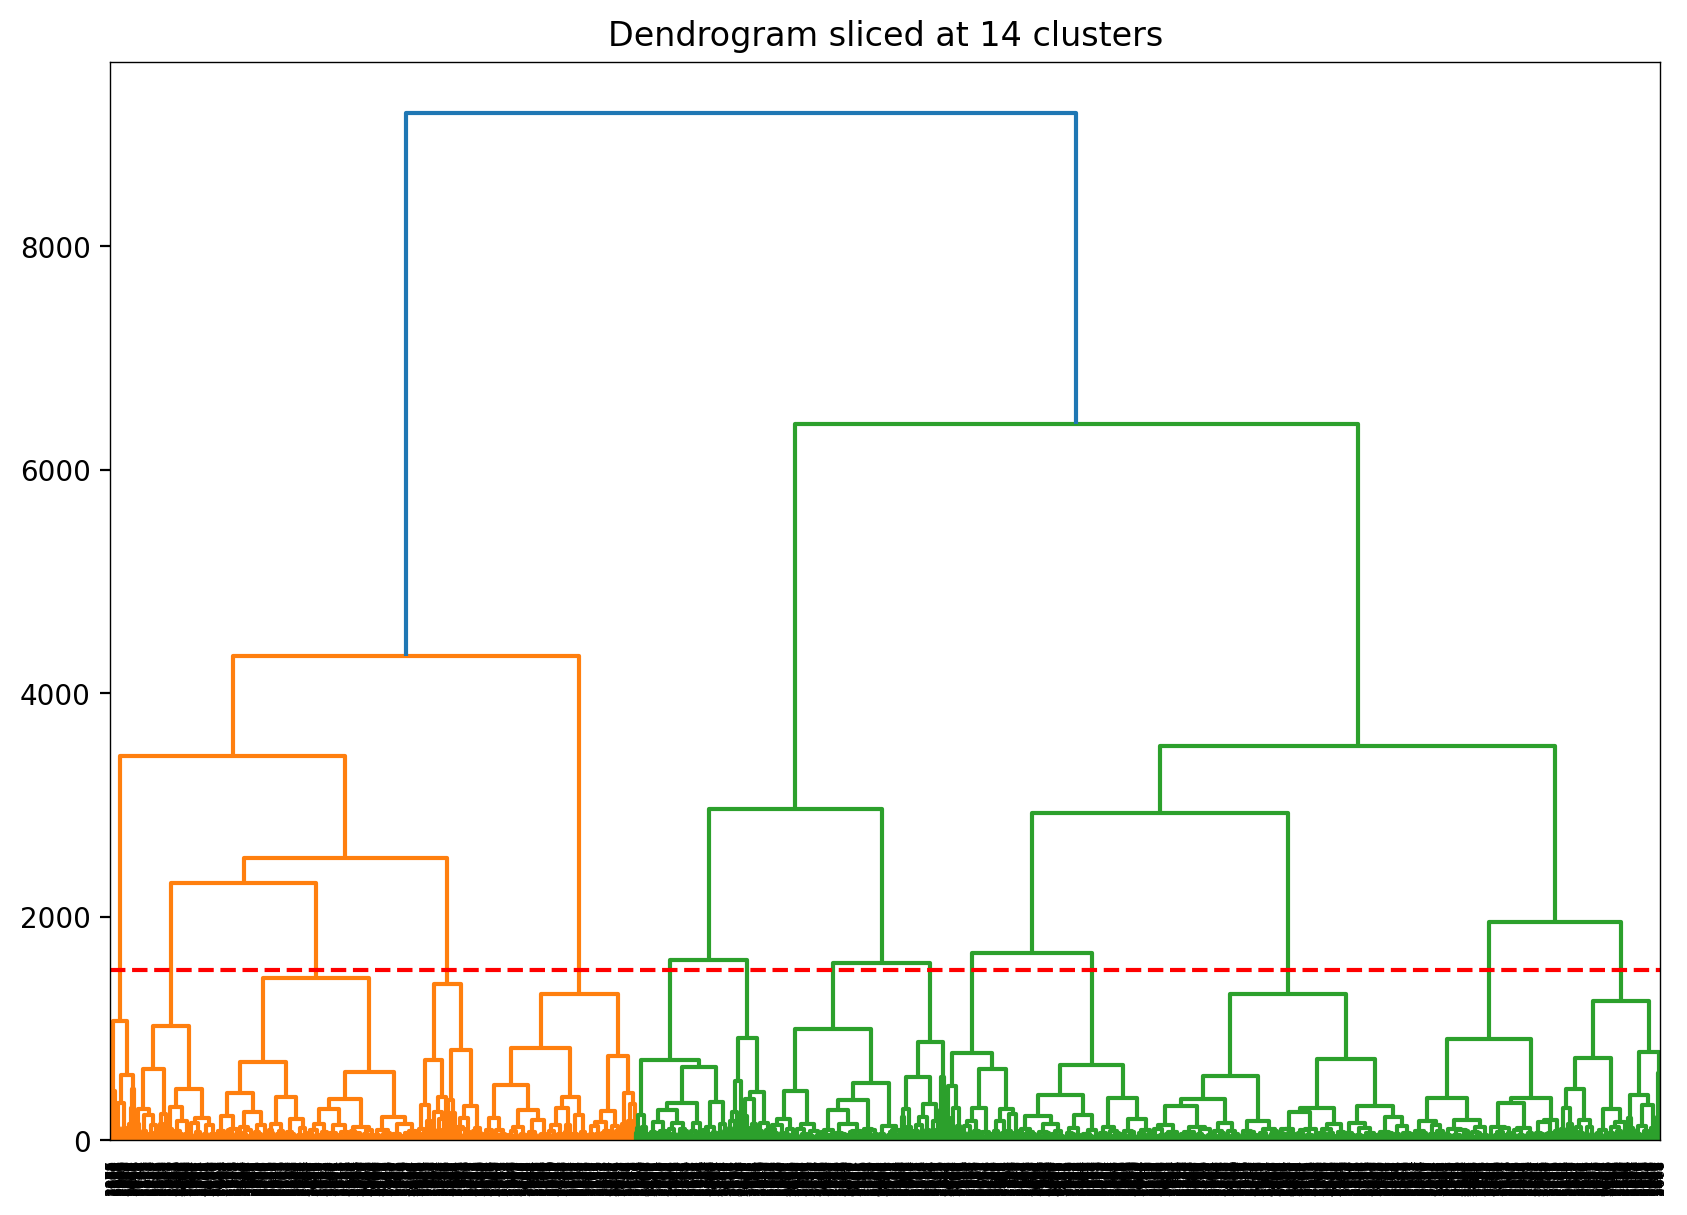

In [26]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming Z is your linkage matrix and k is the number of clusters
Z = row_linkage
k = 14

# 1. Calculate the height threshold for k clusters
# The (n-k)th merge distance in Z[:, 2] determines the split
height = (Z[-(k), 2] + Z[-(k-1), 2]) / 2

# 2. Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)

# 3. Add the horizontal slice line
plt.axhline(y=height, color='r', linestyle='--')
plt.title(f'Dendrogram sliced at {k} clusters')
plt.savefig('/home/wenyuantong/Desktop/figures/dendrogram_100-150_14clusters.png')
plt.show()

In [30]:
reordered_matrix.to_csv("/home/wenyuantong/Desktop/data/arabi_cross/100_150_Ward_reordered.csv", index=True)

In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

In [28]:
df = df_numbered_indices

In [29]:
#GMM

gmm_results = []
max_n_clusters = 25

for n_components in range(2, max_n_clusters):
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(df) # Fit GMM to the DataFrame
    labels = gmm.predict(df) # Predict cluster labels

    # Calculate metrics
    aic = gmm.aic(df)
    bic = gmm.bic(df)

    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster
    silhouette = -1 # Default to -1 if calculation is not possible
    if len(np.unique(labels)) > 1 and df.shape[0] > len(np.unique(labels)):
        try:
            silhouette = silhouette_score(df, labels)
        except ValueError:
            silhouette = -1

    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df.values, labels)

    gmm_results.append({
        'n_clusters': n_components,
        'AIC': aic,
        'BIC': bic,
        'Silhouette_Score': silhouette,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.head())


,n_clusters,AIC,BIC,Silhouette_Score,within_cluster_similarity,between_cluster_similarity
0,2,-1.381424e+08,-5.097397e+07,0.060613,0.819546,0.967058
1,3,-1.241484e+08,6.604233e+06,0.023410,0.839544,0.917386
2,4,-1.101538e+08,6.418306e+07,-0.009220,0.825046,0.835216
3,5,-9.617423e+07,1.217469e+08,-0.049214,0.853452,0.882004
4,6,-8.216809e+07,1.793372e+08,-0.051197,0.851530,0.687511


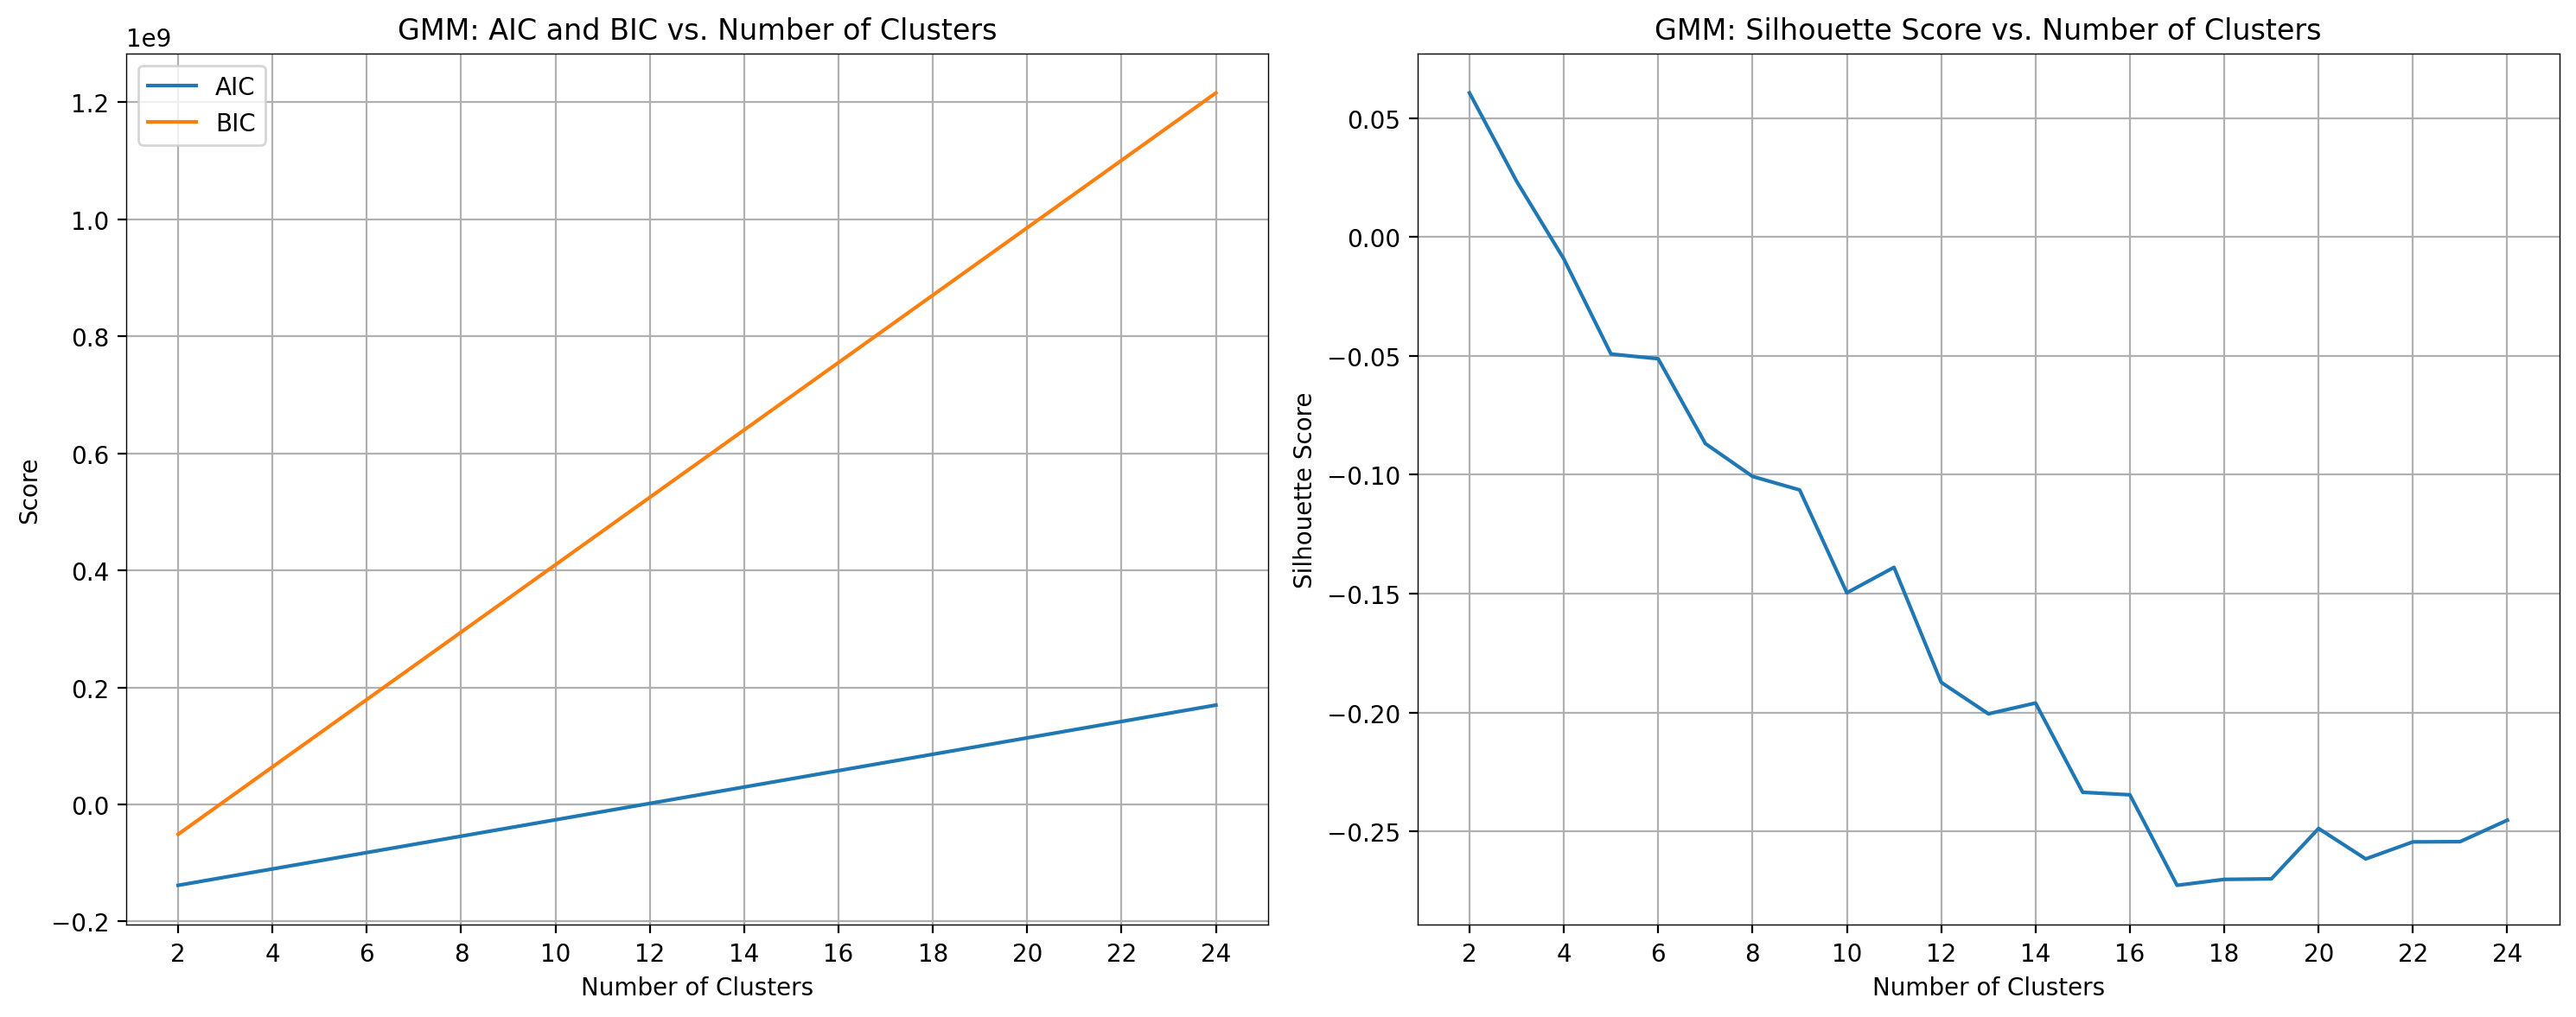

In [31]:
plt.figure(figsize=(15, 6))

# Plot AIC and BIC
plt.subplot(1, 2, 1)
sns.lineplot(x='n_clusters', y='AIC', data=gmm_results_df, label='AIC')
sns.lineplot(x='n_clusters', y='BIC', data=gmm_results_df, label='BIC')
plt.title('GMM: AIC and BIC vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()

# Plot Silhouette Score
plt.subplot(1, 2, 2)
sns.lineplot(x='n_clusters', y='Silhouette_Score', data=gmm_results_df)
plt.title('GMM: Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)

plt.tight_layout()
plt.show()

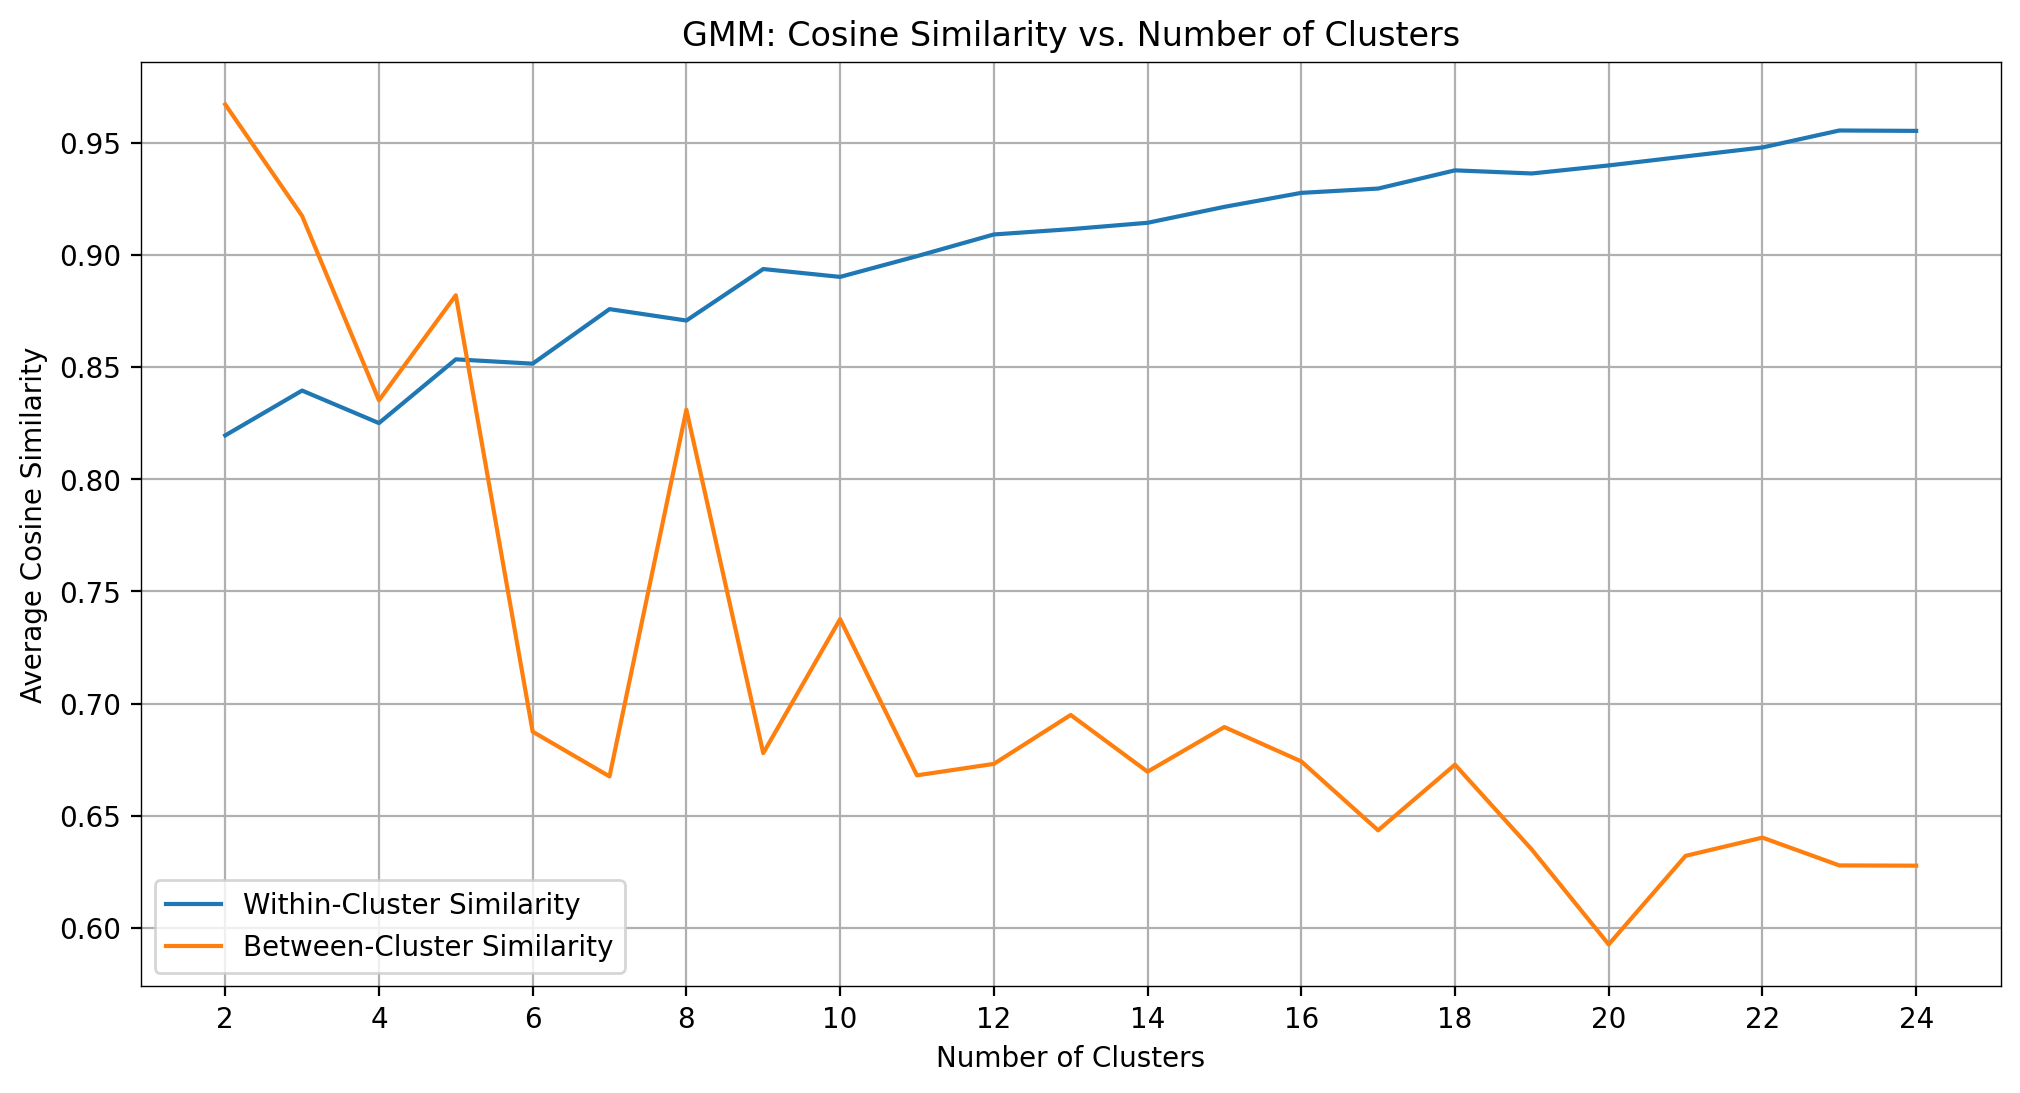

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=gmm_results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=gmm_results_df, label='Between-Cluster Similarity')
plt.title('GMM: Cosine Similarity vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()
plt.show()